In [1]:
import os, random, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

In [2]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 128

epochs = 50
initial_lr = 0.001

device = "cpu"

100%|██████████| 26.4M/26.4M [00:05<00:00, 5.00MB/s]
100%|██████████| 29.5k/29.5k [00:00<?, ?B/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.45MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

60000 10000


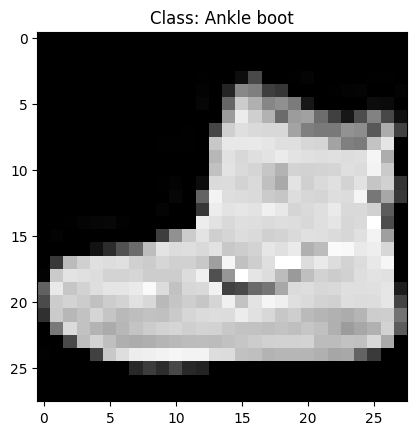

In [3]:
fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

dataset_train = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=True, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)
dataset_test = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=False, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)

train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True)

print(len(train_dataloader.dataset), len(test_dataloader.dataset))

# Визуализация с подписью класса
plt.imshow(dataset_train[0][0].squeeze(), cmap='gray')
plt.title(f"Class: {fashion_classes[dataset_train[0][1]]}")
plt.show()

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

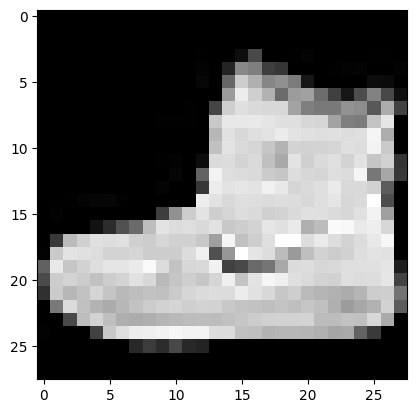

In [4]:
plt.imshow(dataset_train[0][0].reshape(28, 28), cmap='gray')#черно-белое изображение

In [5]:
pd.set_option('display.max_columns', 28)
pd.DataFrame(dataset_train[0][0].reshape(28, 28))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.000000,0.050980,0.286275,0.000000,0.000000,0.003922,0.015686,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011765,0.000000,0.141176,0.533333,0.498039,0.243137,0.211765,0.000000,0.000000,0.000000,0.003922,0.011765,0.015686,0.000000,0.000000,0.011765
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.000000,0.400000,0.800000,0.690196,0.525490,0.564706,0.482353,0.090196,0.000000,0.000000,0.000000,0.000000,0.047059,0.039216,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.607843,0.925490,0.811765,0.698039,0.419608,0.611765,0.631373,0.427451,0.250980,0.090196,0.301961,0.509804,0.282353,0.058824
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.270588,0.811765,0.874510,0.854902,0.847059,0.847059,0.639216,0.498039,0.474510,0.478431,0.572549,0.552941,0.345098,0.674510,0.258824
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.003922,0.000000,0.784314,0.909804,0.909804,0.913725,0.898039,0.874510,0.874510,0.843137,0.835294,0.643137,0.498039,0.482353,0.768627,0.898039,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.717647,0.882353,0.847059,0.874510,0.894118,0.921569,0.890196,0.878431,0.870588,0.878431,0.866667,0.874510,0.960784,0.678431,0.000000


In [6]:
MP1 = nn.MaxPool2d(kernel_size=2, stride= 2)
pd.set_option('display.max_columns', 14)
tmp_MP1 = MP1(dataset_train[0][0])
pd.DataFrame(tmp_MP1.reshape(14, 14))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.050980,0.286275,0.003922,0.015686,0.000000,0.003922,0.003922
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.800000,0.690196,0.564706,0.090196,0.011765,0.047059,0.039216
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.270588,0.925490,0.854902,0.847059,0.631373,0.572549,0.552941,0.674510
4,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.784314,0.909804,0.913725,0.921569,0.878431,0.878431,0.960784,0.898039
5,0.000000,0.000000,0.000000,0.000000,0.003922,0.011765,0.858824,0.894118,0.854902,0.890196,0.854902,0.878431,0.952941,0.819608
6,0.000000,0.000000,0.000000,0.000000,0.015686,0.023529,0.956863,0.901961,0.941176,0.909804,0.874510,0.917647,0.960784,0.654902
7,0.011765,0.015686,0.027451,0.007843,0.243137,0.800000,0.929412,0.874510,0.870588,0.870588,0.878431,0.898039,1.000000,0.623529
8,0.223529,0.815686,0.878431,0.878431,0.894118,0.870588,0.886275,0.960784,0.901961,1.000000,0.917647,0.980392,0.933333,0.964706
9,0.913725,0.894118,0.898039,0.917647,0.976471,0.862745,0.945098,1.000000,0.898039,0.858824,0.866667,0.874510,0.894118,0.898039


In [7]:
pd.set_option('display.max_columns', 7)
pd.DataFrame(MP1(tmp_MP1).reshape(7, 7))

,0,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.050980,0.286275,0.015686,0.003922
1,0.000000,0.000000,0.003922,0.925490,0.854902,0.631373,0.674510
2,0.000000,0.000000,0.011765,0.909804,0.921569,0.878431,0.960784
3,0.015686,0.027451,0.800000,0.956863,0.941176,0.917647,1.000000
4,0.913725,0.917647,0.976471,1.000000,1.000000,0.980392,0.964706
5,0.858824,0.882353,0.847059,0.941176,0.960784,0.870588,0.901961
6,0.007843,0.929412,0.964706,0.956863,0.749020,0.709804,0.388235


In [8]:
MP2 = nn.MaxPool2d(kernel_size=2, stride= 1)
pd.set_option('display.max_columns', 13)
pd.DataFrame(MP2(tmp_MP1).reshape(13, 13))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.050980,0.286275,0.286275,0.015686,0.015686,0.003922,0.003922
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.800000,0.800000,0.690196,0.564706,0.090196,0.047059,0.047059
2,0.000000,0.000000,0.000000,0.000000,0.003922,0.270588,0.925490,0.925490,0.854902,0.847059,0.631373,0.572549,0.674510
3,0.000000,0.000000,0.000000,0.003922,0.003922,0.784314,0.925490,0.925490,0.921569,0.921569,0.878431,0.960784,0.960784
4,0.000000,0.000000,0.000000,0.003922,0.011765,0.858824,0.909804,0.913725,0.921569,0.921569,0.878431,0.960784,0.960784
5,0.000000,0.000000,0.000000,0.015686,0.023529,0.956863,0.956863,0.941176,0.941176,0.909804,0.917647,0.960784,0.960784
6,0.015686,0.027451,0.027451,0.243137,0.800000,0.956863,0.956863,0.941176,0.941176,0.909804,0.917647,1.000000,1.000000
7,0.815686,0.878431,0.878431,0.894118,0.894118,0.929412,0.960784,0.960784,1.000000,1.000000,0.980392,1.000000,1.000000
8,0.913725,0.898039,0.917647,0.976471,0.976471,0.945098,1.000000,1.000000,1.000000,1.000000,0.980392,0.980392,0.964706
9,0.913725,0.898039,0.917647,0.976471,0.976471,0.945098,1.000000,1.000000,0.960784,0.937255,0.874510,0.894118,0.901961


In [9]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation блок (точно по статье)"""
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)
        self.sigmoid = nn.Sigmoid()
        
        # Самое важное: правильная инициализация
        nn.init.constant_(self.fc2.weight, 0.0)   # ← это делает начальные веса ≈ 0.5

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = x.mean(dim=[2, 3])                    # Squeeze
        y = self.fc1(y)
        y = self.relu(y)
        y = self.fc2(y)
        y = self.sigmoid(y)                       # Excitation
        y = y.view(b, c, 1, 1)
        return x * y                              # Scale            

In [10]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.se1   = SEBlock(32)               
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.se2   = SEBlock(64)          
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.se1(x)              
        x = self.pool(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se2(x)            
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.softmax(self.fc2(x), dim=1)
        
        return x

In [11]:
model = SimpleNN()
summary(model, (1, 28, 28), batch_size, device = device)
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 32, 28, 28]             320
       BatchNorm2d-2          [128, 32, 28, 28]              64
            Linear-3                   [128, 4]             128
              ReLU-4                   [128, 4]               0
            Linear-5                  [128, 32]             128
           Sigmoid-6                  [128, 32]               0
           SEBlock-7          [128, 32, 28, 28]               0
         MaxPool2d-8          [128, 32, 14, 14]               0
            Conv2d-9          [128, 64, 14, 14]          18,496
      BatchNorm2d-10          [128, 64, 14, 14]             128
           Linear-11                   [128, 8]             512
             ReLU-12                   [128, 8]               0
           Linear-13                  [128, 64]             512
          Sigmoid-14                  [

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [13]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [14]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 77.2%, Avg loss: 1.688064 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 86.9%, Avg loss: 1.591310 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 88.6%, Avg loss: 1.574954 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 87.8%, Avg loss: 1.582683 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 89.3%, Avg loss: 1.567394 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 89.2%, Avg loss: 1.569119 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 89.7%, Avg loss: 1.564104 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 89.8%, Avg loss: 1.563958 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 90.2%, Avg loss: 1.558102 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 90.0%, Avg loss: 1.559851 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 89.9%, Avg los

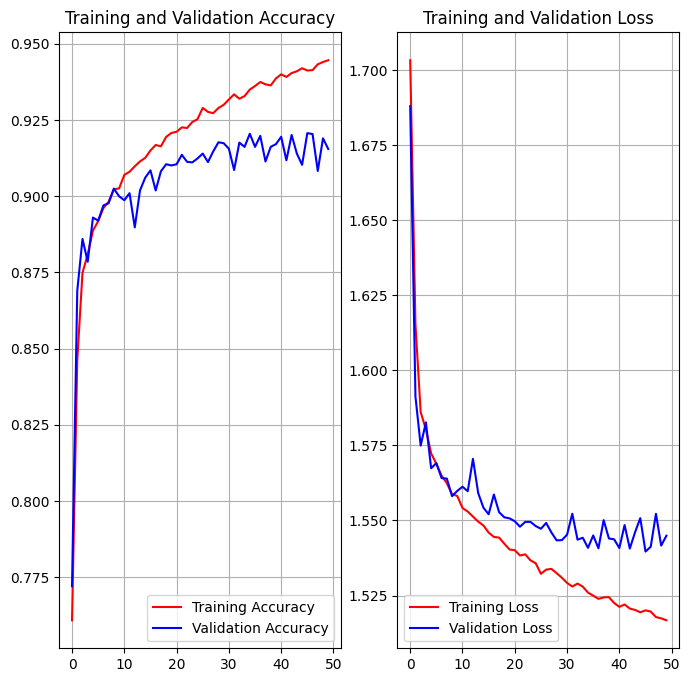

In [15]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [16]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(10, 10, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1
    

In [17]:
pd.set_option('display.max_columns', 10)
pd.DataFrame(cmt.reshape(10, 10))#строка истинное значение, столбец предсказанное

,0,1,2,3,4,5,6,7,8,9
0,929,1,15,9,1,1,39,0,5,0
1,2,983,0,10,1,0,3,0,1,0
2,22,1,900,8,27,0,42,0,0,0
3,25,7,9,925,10,0,23,0,1,0
4,1,0,91,36,820,1,50,0,1,0
5,0,0,0,0,0,978,0,17,0,5
6,155,2,62,25,56,0,692,0,8,0
7,0,0,0,0,0,3,0,969,0,28
8,3,2,2,3,1,2,0,1,986,0
9,0,0,0,0,0,3,0,23,1,973
